In [1]:
import sys
import os

# Add the parent directory (project root) to the Python path
sys.path.append(os.path.abspath(os.path.join('..')))

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from src.ocv_extractor import OCVExtractor

extractor = OCVExtractor(polynomial_order=8)
mock_soc = np.linspace(0, 1, 50)
mock_ocv_anchors = 3.0 + mock_soc * 1.2 + 0.05 * np.sin(mock_soc * np.pi * 4) 

# Fit the polynomial
params = extractor.fit_polynomial(mock_soc, mock_ocv_anchors)
poly_func = extractor.ocv_soc_function
soc_smooth = np.linspace(0, 1, 200)

2026-03-06 13:31:23,610 - INFO - Fitting 8th-order polynomial to OCV-SOC data...
2026-03-06 13:31:23,611 - INFO - Polynomial fitting complete. RMSE: 0.0021 V


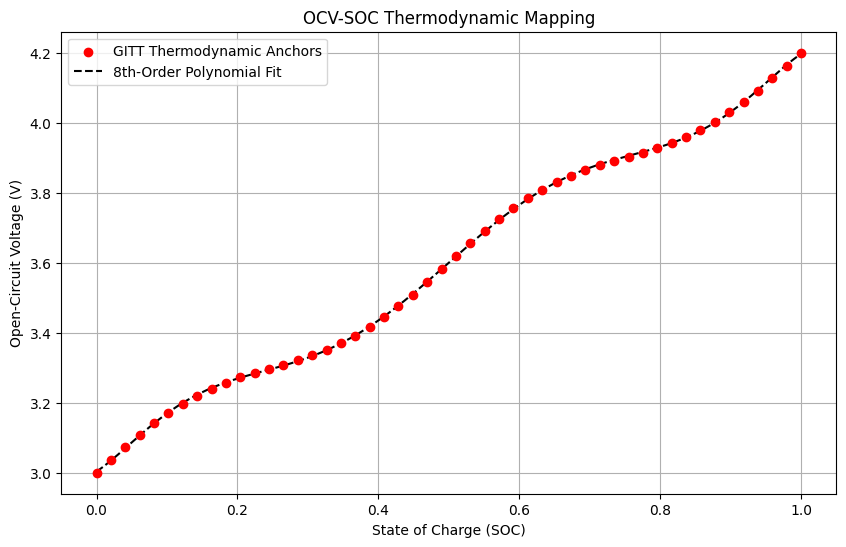

Deployed Polynomial Coefficients:
k8: 4.2812e-10
k7: -1.3547e+02
k6: 4.7413e+02
k5: -6.3295e+02
k4: 3.9705e+02
k3: -1.1415e+02
k2: 1.1239e+01
k1: 1.3392e+00
k0: 3.0034e+00


In [3]:
plt.figure(figsize=(10, 6))
plt.scatter(mock_soc, mock_ocv_anchors, color='red', label='GITT Thermodynamic Anchors', zorder=5)
plt.plot(soc_smooth, poly_func(soc_smooth), color='black', linestyle='--', label='8th-Order Polynomial Fit')
plt.title('OCV-SOC Thermodynamic Mapping')
plt.xlabel('State of Charge (SOC)')
plt.ylabel('Open-Circuit Voltage (V)')
plt.legend()
plt.grid(True)
plt.show()

print("Deployed Polynomial Coefficients:")
for k, v in params.items(): print(f"{k}: {v:.4e}")